# Difference in Normalized Burn Ratio (dNBR) for Fire Area Detection using OpenEO

The main goal of this project is to analyse the impact of forest fires in Portugal. The exact area that was burned in a forest fire is delineated and the burned trees are identified using machine learning methods. 

(The measurement of the impact is split into two parts: the area of the forest that was burned in the forest fire, and the types of vegetation that were burned.
The burned area is identified based on Sentinel-2 images, using the difference in normalized burn ratio (dNBR). For the burned area, labels derived from the national forest inventory are loaded, and used to train a machine learning algorithm to identify the vegetation types in each pixel. This can be used to make an estimate of the composition of the forest and to identify how many hectares of which type of vegetation were burned. )

Key Processes:
1. Calculate dNBR based on image before and after fire
2. Identify composition of the burned forest before the fire using ML
3. Register a UDF for ML
4. Create a story powered by EOPF OpenEO

# Overview

1. Import libraries, define parameters and connect to OpenEO backend
2. Load pre and post fire satellite image
3. Calculate dNBR and Fire Mask 
4. Visualize dNBR and detected burned area

## 1. Import required libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [ ]:
import matplotlib.pyplot as plt
from openeo_udp import ParameterManager
from scipy import ndimage
import numpy as np
import rasterio

### Define Parameters and Connect to OpenEO Backend

Load algorithm parameters from the co-located parameter file and connect to an OpenEO backend with automatic endpoint selection. Choose between CDE and EOPF

In [42]:
# Initialize parameter manager
param_manager = ParameterManager('dNBR_Portugal.params.py')

# Display available options using the built-in helper
param_manager.print_options("dNBR algorithm")

Available parameter sets for dNBR algorithm:
  1. forest_north_portugal_2025: Forest, North Portugal
  2. reriz_gafanhao_north_portugal_2024: Reriz e Gafanhao, North Portugal

Available OpenEO endpoints:
  1. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  2. ds_development: https://openeo.ds.io/
  3. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [44]:
# Connect using the a parameter set for a specified location on the Copernicus Data Space endpoint
connection, current_params = param_manager.quick_connect(
    param_set="reriz_gafanhao_north_portugal_2024",
    endpoint="copernicus_dataspace", # Connecting to CDSE
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: reriz_gafanhao_north_portugal_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Reriz e Gafanhao, North Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


## 2. Load image before and after the fire as separate cubes

In [45]:
# First define functions to use for loading image and calculating NBR
def load_and_sample(params, time, res=100):
    """
    Input: Set of parameters, time frame, desired resolution
    Output: Cube that contains the last image in the time frame 
    """ 
    s2cube = connection.load_collection(
    params["collection"].default,
    temporal_extent=time,
    spatial_extent=params["bounding_box"].default,
    bands=params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= params["cloud_cover"].default,
    },
    )

    s2cube = s2cube.reduce_dimension(dimension="t", reducer="last")

    s2cube = s2cube.resample_spatial(
        resolution=[res, res],
      method="near",
    )

    return s2cube

In [68]:
# Define Resolution
res_dnbr = 20

# Load Satellite image before and after the fire as cubes
s2cube_pre = load_and_sample(current_params, current_params["time_pre"].default, res_dnbr)
s2cube_post = load_and_sample(current_params, current_params["time_post"].default, res_dnbr)

## 3. Calculate dNBR and Fire Mask

In [69]:
### MAIN PROCESS ###
def calculate_nbr(data):
     """ 
     Input: Cube with bands 08 and 12
     Output: NBR
     """
     B08, B12 = (
          data[0],
          data[1],
     )
     nbr = (B08 - B12) / (B08 + B12)
     return nbr

## I combined dNBR calculation and masking to values above 0.3 to simplify process
def calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold):
    dnbr = nbr_pre - nbr_post
    dnbr_mask = dnbr > burn_threshold
    return dnbr, dnbr_mask

In [ ]:
# Calculate NBR of pre and post cube
nbr_post = s2cube_post.reduce_dimension(dimension="bands", reducer=calculate_nbr)
nbr_pre = s2cube_pre.reduce_dimension(dimension="bands", reducer=calculate_nbr)

burn_threshold_default = 0.3
dnbr, dnbr_mask = calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold_default)

In [71]:
# Download dNBR
dnbr_tiff = dnbr.save_result("GTiff")
filename = f"dNBR_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tiff"
connection.download({"process_graph": dnbr_tiff.flat_graph()},filename)

# Download masked dNBR
mask_result = dnbr_mask.save_result("GTiff")
filename_mask = f"firemask_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tif"
connection.download({"process_graph": mask_result.flat_graph(),}, filename_mask)

## 4. Visualize dNBR

In [ ]:
# Importing the downloaded data

with rasterio.open(filename) as src:
    dnbr_gtiff = src.read(1)
    
with rasterio.open(filename_mask) as src:
    mask_gtif = src.read(1)
    trans = src.transform
    crs = src.crs

# Apply connected component labeling to the mask to keep only the largest connected component -> for identifying main area of fire

mask_gtif = ndimage.binary_dilation(mask_gtif, structure=np.ones((3,3)), iterations=1)
labeled, n = ndimage.label(mask_gtif, structure=np.ones((3, 3)))
sizes = ndimage.sum(mask_gtif, labeled, range(1, n + 1))
clean_mask = (labeled == sizes.argmax() + 1).astype("uint8")


In [ ]:
# Plotting original dNBR, masked dNBR, and a clean-up version of masked dNBR side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flat
fig.delaxes(ax4)

im1 = ax1.imshow(dnbr_gtiff, cmap="seismic", vmin=-1, vmax=1)
fig.colorbar(im1, ax=ax1, label="dNBR", shrink=0.8)
ax1.set_title(f"dNBR\n{current_params['location_name']}")
ax1.axis("off")

ax2.imshow(mask_gtif, cmap="gray")
ax2.set_title(f"Burned Area (dNBR > {burn_threshold_default})\n{current_params['location_name']}")
ax2.axis("off")

ax3.imshow(clean_mask, cmap='gray')
ax3.set_title(f"dNBR > {burn_threshold_default} mask\ncleaned up to focus on the largest connected component")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
## NOTES
# # Using CDE either of these three work

# # Arithmetic
# dnbr = nbr_pre - nbr_post

# # With subtract process
# # from openeo.processes import subtract
# # dnbr = nbr_pre.subtract(nbr_post)

# # With merge_cubes
# # dnbr = nbr_pre.merge_cubes(nbr_post, overlap_resolver="subtract")

----

## 5. Load NFI Labels on the burned area

In [ ]:
import geopandas as gpd
from rasterio.transform import rowcol
import matplotlib.patches as mpatches

nfi_labels = gpd.read_file("nfi_labels.geojson")

# # Convert to raster CRS and get pixel coordinates for visualization
# labels_raster_crs = nfi_labels.to_crs(crs)
# rows, cols = rowcol(trans, labels_raster_crs.geometry.x.values, labels_raster_crs.geometry.y.values)

# nfi_labels.head()

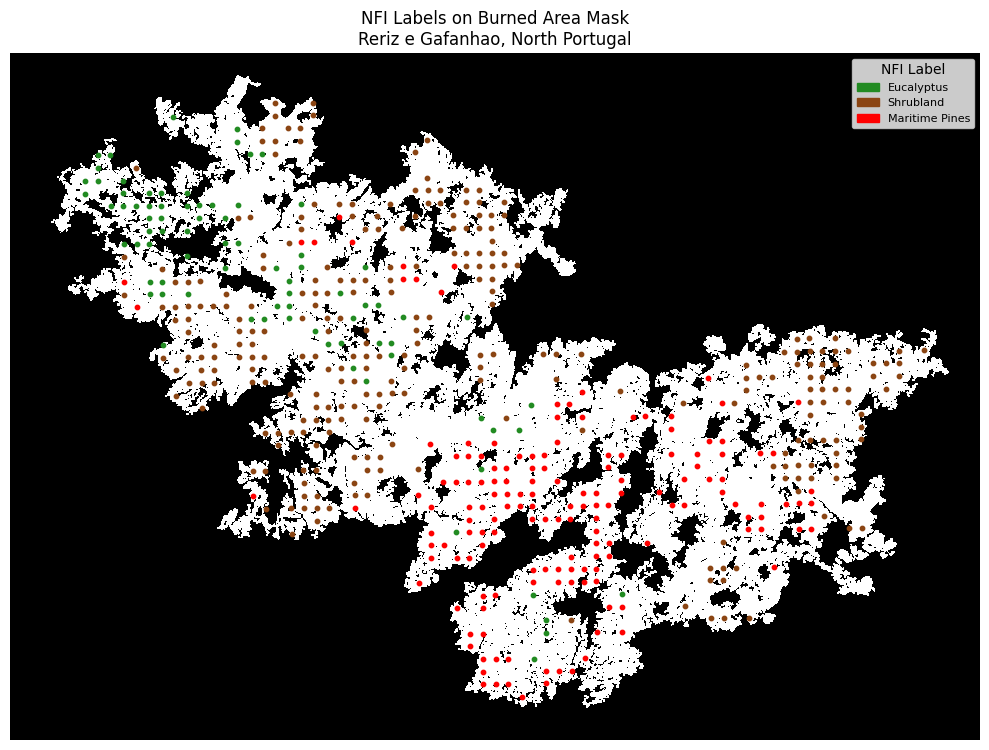

In [ ]:
labels_raster_crs = nfi_labels.to_crs(crs)
rows, cols = rowcol(trans, labels_raster_crs.geometry.x.values, labels_raster_crs.geometry.y.values)

color_map = {
    "Shrubland": "saddlebrown",
    "Eucalyptus": "forestgreen",
    "Maritime Pines": "red",
}
default_color = "gray"

label_classes = nfi_labels["label"].unique()

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clean_mask, cmap="gray", interpolation="none")

for cls in label_classes:
    mask_cls = nfi_labels["label"] == cls
    ax.scatter(cols[mask_cls], rows[mask_cls], s=10,
               color=color_map.get(cls, default_color), label=cls, zorder=2)

legend_patches = [mpatches.Patch(color=color_map.get(cls, default_color), label=cls) for cls in label_classes]
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, title="NFI Label")
ax.set_title(f"NFI Labels on Burned Area Mask\n{current_params['location_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()